Завдання 1. Кореляційна матриця:
          users  sessions  revenue
users      1.00      0.95     0.72
sessions   0.95      1.00     0.78
revenue    0.72      0.78     1.00


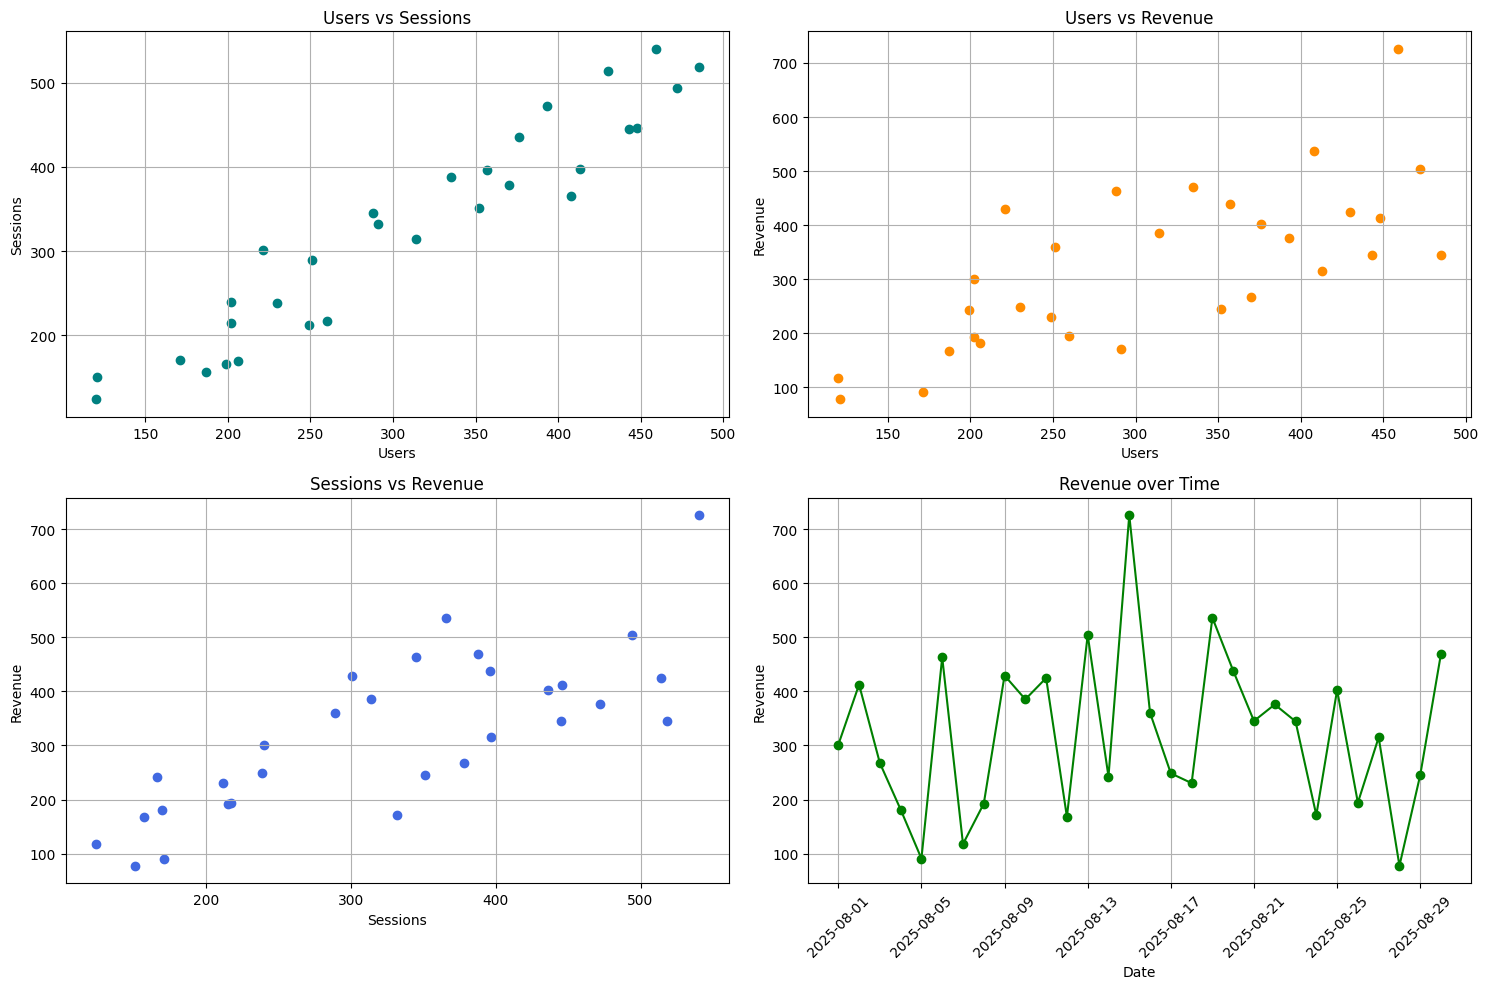

Конверсія в групі A: 0.117 (0.059 – 0.174)
Конверсія в групі B: 0.192 (0.125 – 0.260)
Абсолютна різниця: 0.076
Відносна зміна: 64.84%


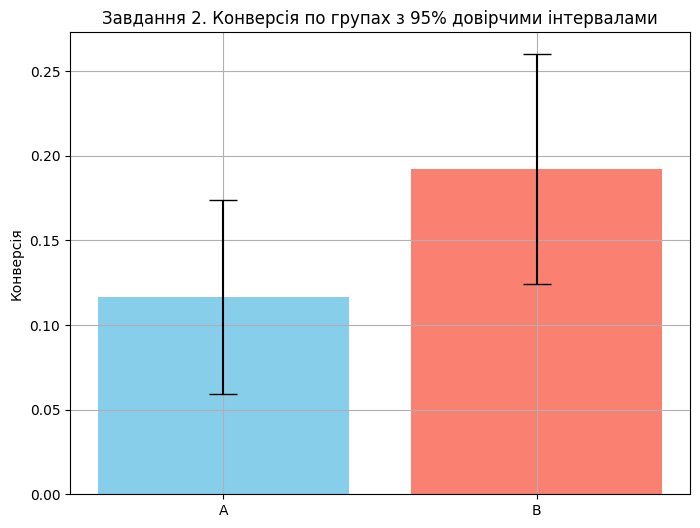

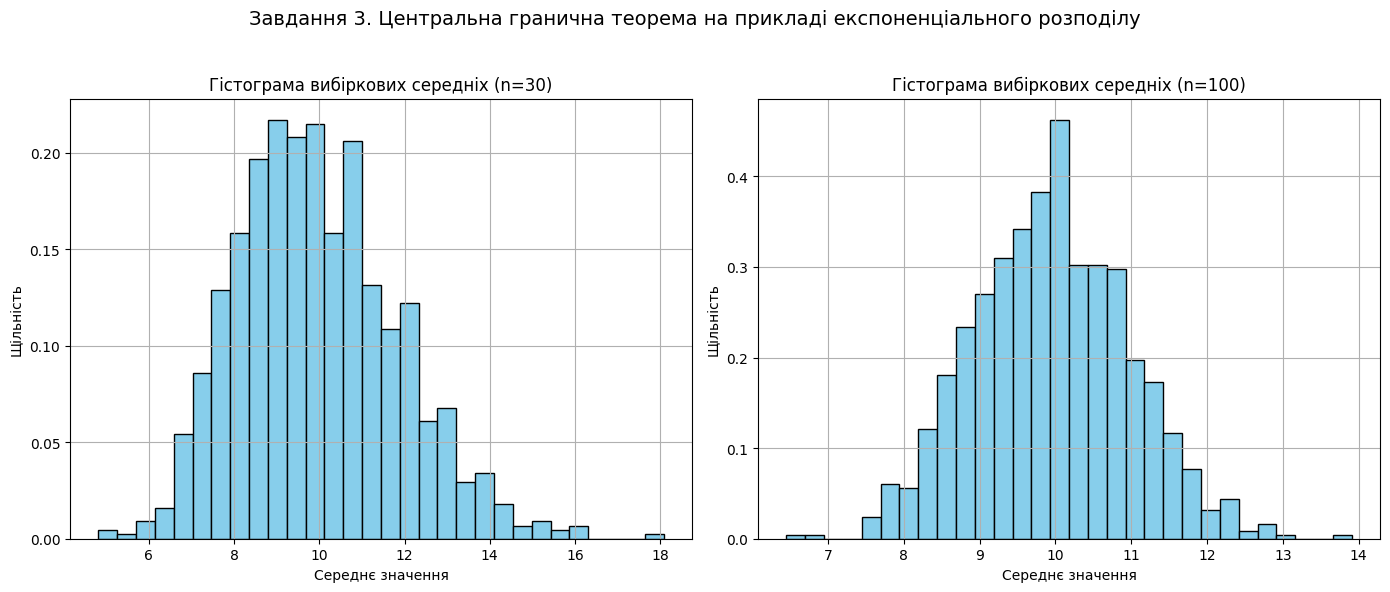

n = 30
Середнє вибіркових середніх: 9.944
Стандартне відхилення: 1.875

n = 100
Середнє вибіркових середніх: 9.945
Стандартне відхилення: 1.024

Завдання 4. Перші рядки з ковзними метриками:
        date   sales  rolling_mean  rolling_std
0 2025-06-01  214.90           NaN          NaN
1 2025-06-02  196.41           NaN          NaN
2 2025-06-03  220.55           NaN          NaN
3 2025-06-04  247.38           NaN          NaN
4 2025-06-05  195.22           NaN          NaN
5 2025-06-06  195.78           NaN          NaN
6 2025-06-07  250.75        217.29        23.90
7 2025-06-08  226.96        219.01        24.13
8 2025-06-09  190.41        218.15        25.15
9 2025-06-10  221.33        218.26        25.17


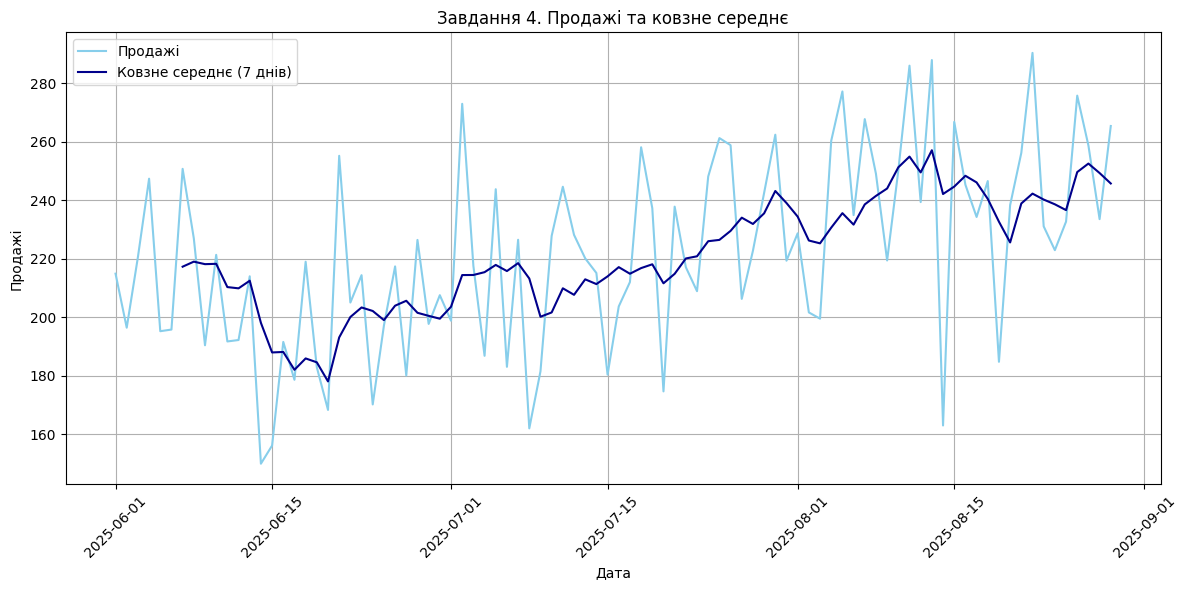

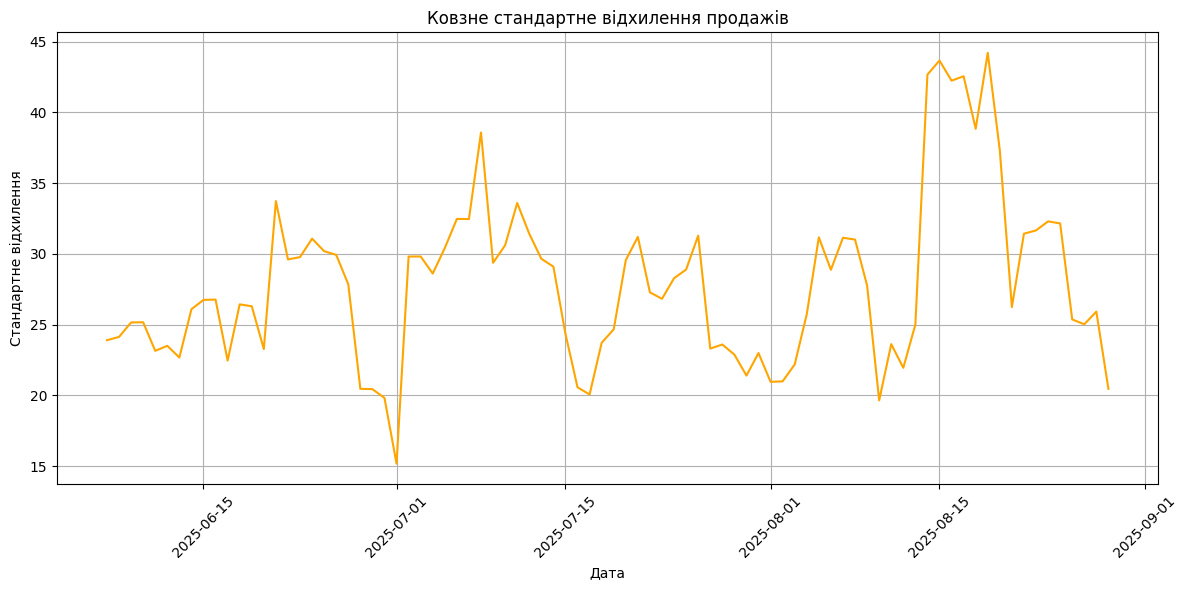

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


"""
Завдання 1
Потрібно проаналізувати взаємозв'язок між користувачами, сесіями та виручкою за днями. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
•	Сформуйте таблицю мінімум на 30 днів із колонками "date", "users", "sessions", "revenue".
•	Розрахуйте кореляційну матрицю для цих метрик.
•	Побудуйте діаграми розсіювання для пар: users-sessions, users-revenue, sessions-revenue.
•	Побудуйте лінійний графік "revenue" за датами.
•	Виведіть матрицю та всі графіки.
"""

dates = pd.date_range(start='2025-08-01', periods=30)

np.random.seed(42)
users = np.random.randint(100, 500, size=30)
sessions = users + np.random.randint(-50, 100, size=30)
revenue = sessions * np.random.uniform(0.5, 1.5, size=30)

df = pd.DataFrame({
    'date': dates,
    'users': users,
    'sessions': sessions,
    'revenue': revenue
})

correlation_matrix = df[['users', 'sessions', 'revenue']].corr()

print("Завдання 1. Кореляційна матриця:")
print(correlation_matrix.round(2))

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(df['users'], df['sessions'], color='teal')
plt.xlabel('Users')
plt.ylabel('Sessions')
plt.title('Users vs Sessions')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.scatter(df['users'], df['revenue'], color='darkorange')
plt.xlabel('Users')
plt.ylabel('Revenue')
plt.title('Users vs Revenue')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.scatter(df['sessions'], df['revenue'], color='royalblue')
plt.xlabel('Sessions')
plt.ylabel('Revenue')
plt.title('Sessions vs Revenue')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(df['date'], df['revenue'], marker='o', color='green')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title('Revenue over Time')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


"""
Завдання 2
Потрібно проаналізувати дані A/B-експерименту та візуалізувати конверсії. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
•	Сформуйте таблицю з полями "group" (A або B) і "converted" (0/1) з не менш ніж 100 спостереженнями в кожній групі.
•	Розрахуйте конверсію в групах, абсолютну різницю та відносну зміну.
•	Побудуйте 95% довірчі інтервали для конверсії в кожній групі.
•	Побудуйте стовпчасту діаграму конверсій груп із відображенням довірчих інтервалів.
•	Виведіть усі розраховані значення та графік.
"""

np.random.seed(42)
n_A, n_B = 120, 130  # кількість спостережень
conv_rate_A = 0.12
conv_rate_B = 0.16

group_A = pd.DataFrame({
    'group': 'A',
    'converted': np.random.binomial(1, conv_rate_A, n_A)
})

group_B = pd.DataFrame({
    'group': 'B',
    'converted': np.random.binomial(1, conv_rate_B, n_B)
})

df = pd.concat([group_A, group_B], ignore_index=True)

conversion_A = df[df['group'] == 'A']['converted'].mean()
conversion_B = df[df['group'] == 'B']['converted'].mean()

abs_diff = conversion_B - conversion_A
rel_change = (conversion_B / conversion_A - 1) * 100

def confidence_interval(p, n, z=1.96):
    se = np.sqrt(p * (1 - p) / n)
    return p - z * se, p + z * se

ci_A = confidence_interval(conversion_A, n_A)
ci_B = confidence_interval(conversion_B, n_B)

print(f"Конверсія в групі A: {conversion_A:.3f} ({ci_A[0]:.3f} – {ci_A[1]:.3f})")
print(f"Конверсія в групі B: {conversion_B:.3f} ({ci_B[0]:.3f} – {ci_B[1]:.3f})")
print(f"Абсолютна різниця: {abs_diff:.3f}")
print(f"Відносна зміна: {rel_change:.2f}%")

fig, ax = plt.subplots(figsize=(8, 6))
groups = ['A', 'B']
conversions = [conversion_A, conversion_B]
errors = [
    conversion_A - ci_A[0],
    conversion_B - ci_B[0]
]

ax.bar(groups, conversions, yerr=errors, capsize=10, color=['skyblue', 'salmon'])
ax.set_ylabel('Конверсія')
ax.set_title('Завдання 2. Конверсія по групах з 95% довірчими інтервалами')
ax.grid(True)

plt.show()


"""
Завдання 3
Потрібно перевірити дію центральної граничної теореми на прикладі несиметричного розподілу. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
•	Згенеруйте генеральну сукупність щонайменше з 50 000 спостережень із несиметричного розподілу.
•	Сформуйте кілька підвибірок фіксованого розміру n і для кожної обчисліть середнє.
•	Збережіть вибіркові середні та побудуйте їхню гістограму.
•	Повторіть процедуру для щонайменше двох різних n і виведіть обидві гістограми.
•	Виведіть середнє і стандартне відхилення вибіркових середніх для кожного n.
"""

np.random.seed(42)
population = np.random.exponential(scale=10, size=50000)

def sample_means(population, sample_size, num_samples=1000):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(population, size=sample_size, replace=False)
        means.append(np.mean(sample))
    return np.array(means)

sample_sizes = [30, 100]

results = {}
for n in sample_sizes:
    means = sample_means(population, sample_size=n)
    results[n] = {
        'means': means,
        'mean': np.mean(means),
        'std': np.std(means)
    }

plt.figure(figsize=(14, 6))

for i, n in enumerate(sample_sizes):
    plt.subplot(1, 2, i+1)
    plt.hist(results[n]['means'], bins=30, color='skyblue', edgecolor='black', density=True)
    plt.title(f'Гістограма вибіркових середніх (n={n})')
    plt.xlabel('Середнє значення')
    plt.ylabel('Щільність')
    plt.grid(True)

plt.suptitle('Завдання 3. Центральна гранична теорема на прикладі експоненціального розподілу', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

for n in sample_sizes:
    print(f"n = {n}")
    print(f"Середнє вибіркових середніх: {results[n]['mean']:.3f}")
    print(f"Стандартне відхилення: {results[n]['std']:.3f}")
    print()


"""
Завдання 4
Потрібно проаналізувати часовий ряд продажів і візуалізувати ковзаючі метрики. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
•	Сформуйте таблицю "date" і "sales" за 90 днів.
•	Додайте ковзне середнє і ковзне стандартне відхилення за обраним вікном.
•	Побудуйте графік вихідних продажів і графік ковзного середнього на одному полі.
•	Побудуйте окремий графік ковзного стандартного відхилення.
•	Виведіть таблицю з першими рядками нових стовпців і обидва графіки.
"""

dates = pd.date_range(start='2025-06-01', periods=90)

np.random.seed(42)
sales = np.random.normal(loc=200, scale=30, size=90) + np.linspace(0, 50, 90)

df = pd.DataFrame({
    'date': dates,
    'sales': sales
})

window = 7
df['rolling_mean'] = df['sales'].rolling(window=window).mean()
df['rolling_std'] = df['sales'].rolling(window=window).std()

print("Завдання 4. Перші рядки з ковзними метриками:")
print(df.head(10).round(2))

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['sales'], label='Продажі', color='skyblue')
plt.plot(df['date'], df['rolling_mean'], label=f'Ковзне середнє ({window} днів)', color='darkblue')
plt.xlabel('Дата')
plt.ylabel('Продажі')
plt.title('Завдання 4. Продажі та ковзне середнє')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['rolling_std'], label=f'Ковзне std ({window} днів)', color='orange')
plt.xlabel('Дата')
plt.ylabel('Стандартне відхилення')
plt.title('Ковзне стандартне відхилення продажів')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

